In [1]:
import numpy as np
import sys
from pathlib import Path

sys.path.append('../code/')

from mlalgos import HyperOpt
from mllib import Utilities,MLUtilities

from time import time
import copy,pickle

import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol
import gc

ut = Utilities()
ml = MLUtilities()

In [2]:
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14 # 14
mpl.rcParams['legend.labelspacing'] = 0.25
FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3

#mpl.rcParams.keys()

# Example usage of `HyperOpt` 
### for systematically searching over network architectures and hyperparameters

In [3]:
Plot_Stem = 'hyperopt/plots'
Path(Plot_Stem).mkdir(parents=True,exist_ok=True)

Nproc = 16

Save_Fig = True

In [4]:
Shallow = True # True: shallow+wide arch; False: deep+narrow arch; None: telescoping arch
Fixed_Width = True # can be False for deep networks
if Shallow is not None:
    Depth_Str_Root = 'shallow' if Shallow else 'deep'
    if Shallow:
        Fixed_Width = True # don't randomize widths in shallow networks
else:
    Depth_Str_Root = 'telescopic'
    Fixed_Width = None
Plot_Str_Root = '' + Depth_Str_Root

Standardize_X = True # whether or not to standardize features
Standardize_Y = True # whether or not to standardize labels (only relevant for regression)

if Standardize_X:
    if Standardize_Y:
        Std_Str = 'stdXstdY'
    else:
        Std_Str = 'stdX'
else:
    if Standardize_Y:
        Std_Str = 'stdY'
    else:
        Std_Str = 'nostd'
Depth_Str = Depth_Str_Root + '/' + Std_Str
Plot_Str_Root += '_' + Std_Str
print(Depth_Str,Plot_Str_Root)

Std_Text = 'std: '
if Standardize_X:
    Std_Text += 'X,Y' if Standardize_Y else 'X'
else:
    Std_Text += 'Y' if Standardize_Y else 'none'

shallow/stdXstdY shallow_stdXstdY


## Optimization of `Sequential`

In [5]:
Family = 'seq'

Decay_Norm = 2 # 1 or 2
DN_Str = '/dn{0:d}'.format(Decay_Norm)

### Regression example: 1-d Gaussian, power-sine families

#### Function definitions

In [6]:
def func_gauss1d(x,params):
    """ Expect x as 1-d array, params as array of shape (0,), (1,) or (2,). """
    mu = params[0] if len(params) > 0 else 0.0
    sig2 = 10**params[1] if len(params) > 1 else 1.0
    return np.exp(-0.5*(x-mu)**2/sig2)/np.sqrt(2*np.pi*sig2)

def func_powersine(x,params):
    """ Expect x as 1-d array, params as array of shape (0,), (1,), (2,) or (3,). """
    A = params[0] if len(params) > 0 else 1.0
    exponent = params[1] if len(params) > 1 else 0.0
    phase = params[2] if len(params) > 2 else 0.0
    return A*np.fabs(x)**exponent*np.sin(x + phase)**2

#### Training & testing samples

In [7]:
Ftype = 'psin'

ExDict = {'gf1d':{'root':'gf1d/','text':'1-d Gaussian',
                  'func':func_gauss1d,'xbounds':[-2.5,3.0],
                  'pbounds':{'min':[-0.5,-0.2], # minimum mu,lgsig2
                             'max':[ 0.5, 0.2]} # maximum mu,lgsig2
                 },
          'psin':{'root':'psin/','text':'Power-Sine',
                  'func':func_powersine,'xbounds':[0.0,1.5*np.pi],
                  'pbounds':{'min':[-1.0,0.0,-np.pi/9], # minimum A,expo,phase
                             'max':[ 1.0,0.2, np.pi/9]} # maximum A,expo,phase
                 }
         }

if Ftype not in ExDict.keys():
    raise Exception("FType must be one of ["+','.join(key for key in list(ExDict.keys()))+']')

Example_Root = Family + '/' + ExDict[Ftype]['root'] + Depth_Str + DN_Str
Plot_Root = Family + '_' + ExDict[Ftype]['root'][:-1] + '_' + Plot_Str_Root + '_' + DN_Str[1:]
if Shallow == False:
    FW_Str = 'fixwid' if Fixed_Width else 'ranwid'
    Example_Root += '/' + FW_Str
    Plot_Root += '_' + FW_Str
print(Example_Root,Plot_Root)

Example_Text = ExDict[Ftype]['text']

example_func = ExDict[Ftype]['func']
xmin,xmax = ExDict[Ftype]['xbounds']
param_mins = ExDict[Ftype]['pbounds']['min'] 
param_maxs = ExDict[Ftype]['pbounds']['max'] 


seq/psin/shallow/stdXstdY/dn2 seq_psin_shallow_stdXstdY_dn2


Generating data for Power-Sine family...
... training sample
... sample of size 2500 created
... testing sample
... sample of size 15000 created
... done
0 min 0.01 seconds



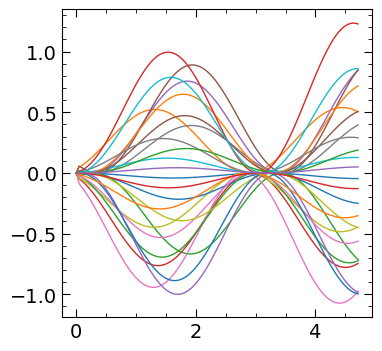

(4, 2500) (1, 2500)


In [8]:
start_time = time()

print('Generating data for '+Example_Text+' family...')

seed = 1983
rng = np.random.RandomState(seed)

#################################################
# Training set
print('... training sample')
n_x_train = 100
xtrain = np.linspace(xmin,xmax,n_x_train)

n_lhc_train = 25 # no. of Latin hypercube samples
n_params = len(param_mins)

# LHC of shape (n_lhc_train,n_params)
if len(param_mins) > 0:
    params_train = ut.gen_latin_hypercube(Nsamp=n_lhc_train,dim=n_params,param_mins=param_mins,param_maxs=param_maxs,rng=rng) 
else:
    params_train = [[]]

n_train = n_lhc_train*n_x_train

X_train = np.zeros((n_train,n_params+1)) # features = {params},x; X will be transposed later
Y_train = np.zeros((1,n_train))

for n in range(n_lhc_train):
    sl = np.s_[n*n_x_train:(n+1)*n_x_train]
    for p in range(n_params):
        X_train[sl,p] = params_train[n,p]
    X_train[sl,-1] = xtrain
    Y_train[0,sl] = example_func(xtrain,params_train[n])

X_train = X_train.T
print('... sample of size {0:d} created'.format(n_train))
#################################################
# Testing set
print('... testing sample')
n_x_test = 200
xtest = (xmax-xmin)*rng.random_sample(n_x_test) + xmin

n_lhc_test = 75 # no. of Latin hypercube samples

# LHC of shape (n_lhc_test,n_params)
if len(param_mins) > 0:
    params_test = ut.gen_latin_hypercube(Nsamp=n_lhc_test,dim=n_params,param_mins=param_mins,param_maxs=param_maxs,rng=rng) 
else:
    params_test = [[]]

n_test = n_lhc_test*n_x_test

X_test = np.zeros((n_test,n_params+1)) # features = {params},x; X will be transposed later
Y_test = np.zeros((1,n_test))

for n in range(n_lhc_test):
    sl = np.s_[n*n_x_test:(n+1)*n_x_test]
    for p in range(n_params):
        X_test[sl,p] = params_test[n,p]
    X_test[sl,-1] = xtest
    Y_test[0,sl] = example_func(xtest,params_test[n])

X_test = X_test.T
print('... sample of size {0:d} created'.format(n_test))
print('... done')
ut.time_this(start_time)

plt.figure(figsize=(4,4))
for n in range(n_lhc_train):
    sl = np.s_[n*n_x_train:(n+1)*n_x_train]
    plt.plot(xtrain,Y_train[0,sl],lw=1)
plt.minorticks_on()
plt.show()
print(X_train.shape,Y_train.shape)

#### Network setup and training

In [9]:
# dictionary containing all setup parameters and data
setup_dict = {} 

# -- data set: features and labels
setup_dict['X'] = X_train
setup_dict['Y'] = Y_train

# -- network family
setup_dict['family'] = Family

# -- training sample 
setup_dict['train_frac'] = 0.8
setup_dict['val_frac'] = 0.2
setup_dict['loss_type'] = 'square'
setup_dict['neg_labels'] = True # irrelevant for regression

# -- training setup
setup_dict['standardize_X'] = Standardize_X
setup_dict['standardize_Y'] = Standardize_Y
setup_dict['max_epoch'] = 3000
setup_dict['check_after'] = 300 if Shallow else 1000
setup_dict['decay_norm'] = Decay_Norm
setup_dict['test_type'] = 'perc' if Ftype=='gf1d' else 'mse'
setup_dict['seed'] = None
setup_dict['file_stem'] = 'net' # will be changed later

#-----------------------
# total number of networks trained will be n_iter * max_config
N_Iter = 3
Max_Config = 64
setup_dict['n_iter'] = N_Iter
setup_dict['max_config'] = Max_Config
#-----------------------

setup_dict['ensemble'] = False  # will be changed
setup_dict['ensemble_size'] = 3 # as needed

setup_dict['parallel'] = True
setup_dict['nproc'] = np.min([Nproc,N_Iter*Max_Config])
setup_dict['fixed_width'] = Fixed_Width

# -- sampled parameters
setup_dict['layers'] = {'min':2 if Shallow else 8,
                        'max':4 if Shallow else 32}
setup_dict['widths'] = {'min': 50 if Shallow else 4,
                        'max':200 if Shallow else 8}
setup_dict['lglrates'] = {'min':-4.5,'max':-1.5}
setup_dict['wt_decays'] = {'min':0.0,'max':0.5}
setup_dict['thresholds'] = None
setup_dict['htypes'] = ['tanh','lrelu','sin']
setup_dict['lrelu_slopes'] = {'min':-1e-2,'max':1e-2}
setup_dict['reg_funs'] = ['bn','drop','none']
setup_dict['p_drops'] = {'min':0.0,'max':0.5}
setup_dict['dream_schedules'] = None

# -- I/O
setup_dict['verbose'] = True
setup_dict['logfile'] = None

##### Non-ensembled

In [10]:
Optimize = True

Example_Stem_Single = Example_Root +'/sing'

File_Stem = 'hyperopt/' + Example_Stem_Single
print('File_Stem:',File_Stem)

setup_dict_sing = copy.deepcopy(setup_dict)
setup_dict_sing['file_stem'] = File_Stem
setup_dict_sing['ensemble'] = False

start_time = time()
hopt_sing = HyperOpt(setup_dict=setup_dict_sing)

if Optimize:
    net,params_train,bts = hopt_sing.optimize()
else:
    net = hopt.load()
    params_train,bts = hopt_sing.load_train()

ut.time_this(start_time)

File_Stem: hyperopt/seq/psin/shallow/stdXstdY/dn2/sing
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... found data set of dimension 4 with targets of dimension 1
... found 2500 samples
... fraction 0.800 (2000 samples) will be used for training
... will search over 3 iterations of 64 configurations
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 16 process(es)
[....................] 100% done
[..................  ] 94% done
... identifying and saving best network and its teststat and training params
14 min 59.25 seconds



Best test stat = 4.428e-03
Setup params:
... L: 3
... wt_decay: 0.171875
... n_layer: [144, 144, 1]
... atypes: [np.str_('tanh'), np.str_('tanh'), 'lin']
... reg_fun: none
... check_after: 300
... lrate: 1.98e-04
No. of free params optimized = 21745



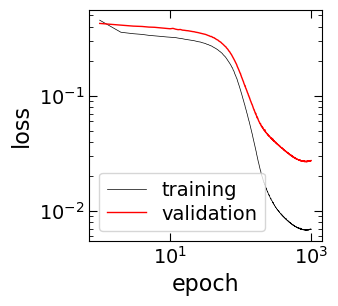

In [11]:
Ypred_sing = net.predict(X_test)
show_keys = ['L','wt_decay','n_layer','atypes','reg_fun']

print('Best test stat = {0:.3e}'.format(bts))
print('Setup params:')
for pkey in show_keys:
    print('... '+pkey+':',net.params[pkey])
    if pkey == 'atypes':
        if 'lrelu' in net.params[pkey]:
            print('... ... lrelu_slope: {0:.2e}'.format(net.params['lrelu_slope']))
print('... check_after: {0:d}'.format(params_train['check_after']))
print('... lrate: {0:.2e}'.format(params_train['lrate']))

print('No. of free params optimized = {0:d}\n'.format(net.calc_N_freeparams()))

plt.figure(figsize=(3,3))
plt.yscale('log')
plt.xscale('log')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.plot(net.epochs,net.training_loss,'k-',lw=0.5,label='training')
plt.plot(net.epochs,net.val_loss,'r-',lw=1,label='validation')
plt.legend()
plt.show()

residual_sing = np.squeeze(Ypred_sing/(Y_test + 1e-15) - 1)


##### Ensembled

In [12]:
Optimize = True

Example_Stem_Ens = Example_Root +'/ens'

File_Stem = 'hyperopt/' + Example_Stem_Ens
print('File_Stem:',File_Stem)

setup_dict_ens = copy.deepcopy(setup_dict)
setup_dict_ens['file_stem'] = File_Stem
setup_dict_ens['ensemble'] = True
setup_dict_ens['ensemble_size'] = 10

start_time = time()
hopt_ens = HyperOpt(setup_dict=setup_dict_ens)

if Optimize:
    neo = hopt_ens.optimize()
else:
    neo = hopt_ens.load() 

ut.time_this(start_time)

File_Stem: hyperopt/seq/psin/shallow/stdXstdY/dn2/ens
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... found data set of dimension 4 with targets of dimension 1
... found 2500 samples
... fraction 0.800 (2000 samples) will be used for training
... will search over 3 iterations of 64 configurations
... will store best 10 networks in ensemble
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 16 process(es)
[....................] 100% done
[..................  ] 92% done... defining and loading NetworkEnsembleObject
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
17 min 3.74 seconds



Best test stats:
... hyperopt/seq/psin/shallow/stdXstdY/dn2/ens/ensemble/net_r0: 2.327e-03
... ... L: 3
... ... wt_decay: 0.0
... ... n_layer: [144, 144, 1]
... ... atypes: [np.str_('tanh'), np.str_('tanh'), 'lin']
... ... reg_fun: none
... ... check_after: 300
... ... lrate: 1.43e-04
... hyperopt/seq/psin/shallow/stdXstdY/dn2/ens/ensemble/net_r1: 2.839e-03
... ... L: 4
... ... wt_decay: 0.03125
... ... n_layer: [165, 165, 165, 1]
... ... atypes: [np.str_('sin'), np.str_('sin'), np.str_('sin'), 'lin']
... ... reg_fun: none
... ... check_after: 300
... ... lrate: 6.49e-04
... hyperopt/seq/psin/shallow/stdXstdY/dn2/ens/ensemble/net_r2: 2.870e-03
... ... L: 4
... ... wt_decay: 0.03125
... ... n_layer: [165, 165, 165, 1]
... ... atypes: [np.str_('sin'), np.str_('sin'), np.str_('sin'), 'lin']
... ... reg_fun: none
... ... check_after: 300
... ... lrate: 6.49e-04
... hyperopt/seq/psin/shallow/stdXstdY/dn2/ens/ensemble/net_r3: 2.915e-03
... ... L: 3
... ... wt_decay: 0.0
... ... n_layer: [144

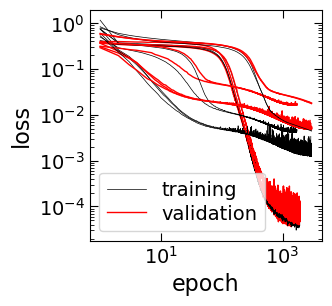

17 min 4.39 seconds



In [13]:
Ypred_ens = neo.predict(X_test)
show_keys = ['L','wt_decay','n_layer','atypes','reg_fun']

print('Best test stats:')
for key in neo.keys:
    print('... '+key+': {0:.3e}'.format(neo.ensemble[key]['teststat']))
    for pkey in show_keys:
        print('... ... '+pkey+':',neo.ensemble[key]['net'].params[pkey])
        if pkey == 'atypes':
            if 'lrelu' in neo.ensemble[key]['net'].params[pkey]:
                print('... ... lrelu_slope: {0:.2e}'.format(neo.ensemble[key]['net'].params['lrelu_slope']))
    print('... ... check_after: {0:d}'.format(neo.ensemble[key]['ptrain']['check_after']))
    print('... ... lrate: {0:.2e}'.format(neo.ensemble[key]['ptrain']['lrate']))

print('No. of free params optimized:')
ens_avg_Nwts = []
for key in neo.keys:
    nwts_this = neo.ensemble[key]['net'].calc_N_freeparams()
    print('... '+key+': {0:d}'.format(nwts_this))
    ens_avg_Nwts.append(nwts_this)
ens_avg_Nwts = np.mean(ens_avg_Nwts)
print('... average: {0:.1f}'.format(ens_avg_Nwts))

plt.figure(figsize=(3,3))
plt.yscale('log')
plt.xscale('log')
plt.xlabel('epoch')
plt.ylabel('loss')
for n in range(len(neo.keys)):
    key = neo.keys[n]
    net_this = neo.ensemble[key]['net']
    plt.plot(net_this.epochs,net_this.training_loss,'k-',lw=0.5,label='training' if n==0 else None)
    plt.plot(net_this.epochs,net_this.val_loss,'r-',lw=1,label='validation' if n==0 else None)
    del net_this
plt.legend()
plt.show()

residual_ens = np.squeeze(Ypred_ens/(Y_test + 1e-15) - 1)

ut.time_this(start_time)

Writing to file: hyperopt/plots/seq_psin_shallow_stdXstdY_dn2.png
median +- 1sigma
...   single: 0.0862 + 7.7772 - 5.2780 %
... ensemble: -0.0309 + 6.0571 - 6.6027 %


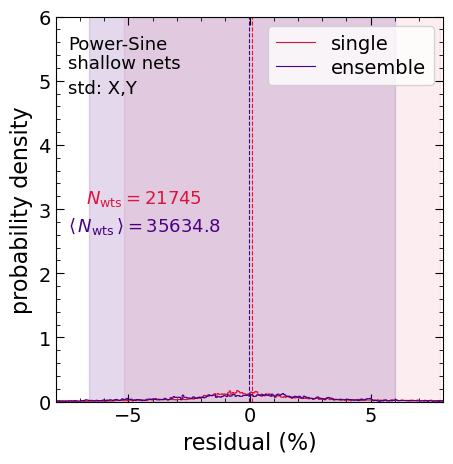

In [14]:
res_sing_16pc = np.percentile(residual_sing,16)*100
res_sing_med  = np.median(residual_sing)*100
res_sing_84pc = np.percentile(residual_sing,84)*100

res_ens_16pc = np.percentile(residual_ens,16)*100
res_ens_med  = np.median(residual_ens)*100
res_ens_84pc = np.percentile(residual_ens,84)*100

bins = np.linspace(-25,25,801)
bin_mid = 0.5*(bins[1:]+bins[:-1])
hist_sing,bins = np.histogram(residual_sing*100,bins=bins,density=False)
hist_sing = hist_sing/residual_sing.size/(bins[1]-bins[0])
hist_ens,bins = np.histogram(residual_ens*100,bins=bins,density=False)
hist_ens = hist_ens/residual_ens.size/(bins[1]-bins[0])

XLoc  = 1.5 if Ftype=='gf1d' else 8.0
dXLoc = 0.1 if Ftype=='gf1d' else 0.5
cols = ['crimson','indigo']
plt.figure(figsize=(5,5))
plt.xlim(-XLoc,XLoc)
plt.ylim(0,6)
plt.xlabel('residual (%)')
plt.ylabel('probability density')
plt.plot(bin_mid,hist_sing,'-',c=cols[0],lw=0.8,drawstyle='steps',label='single')
plt.axvline(res_sing_med,c=cols[0],ls='--',lw=0.8)
plt.fill_betweenx(np.linspace(0,7,10),res_sing_16pc,res_sing_84pc,color=cols[0],alpha=0.075)
plt.plot(bin_mid,hist_ens,'-',c=cols[1],lw=0.8,drawstyle='steps',label='ensemble')
plt.axvline(res_ens_med,c=cols[1],ls='--',lw=0.8)
plt.fill_betweenx(np.linspace(0,7,10),res_ens_16pc,res_ens_84pc,color=cols[1],alpha=0.15)
plt.minorticks_on()
plt.legend(loc='upper right')
plt.text(-XLoc+dXLoc,5.5,Example_Text,fontsize=FS3)
plt.text(-XLoc+dXLoc,5.2,Depth_Str_Root+' nets',fontsize=FS3)
plt.text(-XLoc+dXLoc,4.8,Std_Text,fontsize=FS3)
plt.text(-XLoc+dXLoc*2.5,3.1,'$N_{{\\rm wts}} = {0:d}$'.format(net.calc_N_freeparams()),fontsize=FS3,c=cols[0])
plt.text(-XLoc+dXLoc,2.65,'$\\langle \\, N_{{\\rm wts}} \\, \\rangle = {0:.1f}$'.format(ens_avg_Nwts),fontsize=FS3,c=cols[1])
if Save_Fig:
    outfile = Plot_Stem + '/' + Plot_Root + '.png'
    print('Writing to file: '+outfile)
    plt.savefig(outfile,bbox_inches='tight')
else:
    plt.show()

print('median +- 1sigma')
print('...   single: {0:.4f} + {1:.4f} - {2:.4f} %'.format(res_sing_med,res_sing_84pc-res_sing_med,res_sing_med-res_sing_16pc))
print('... ensemble: {0:.4f} + {1:.4f} - {2:.4f} %'.format(res_ens_med,res_ens_84pc-res_ens_med,res_ens_med-res_ens_16pc))

##### Testing activations

File_Stem: hyperopt/seq/psin/shallow/stdXstdY/dn2/act/tanh
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... found data set of dimension 4 with targets of dimension 1
... found 2500 samples
... fraction 0.800 (2000 samples) will be used for training
... will search over 3 iterations of 64 configurations
... will store best 10 networks in ensemble
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 16 process(es)
[....................] 100% done
[................... ] 98% done... defining and loading NetworkEnsembleObject
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
Best test stats:
... hyperopt/seq/psin/shallow/stdXstdY/dn2/act/tanh/ensemble/net_

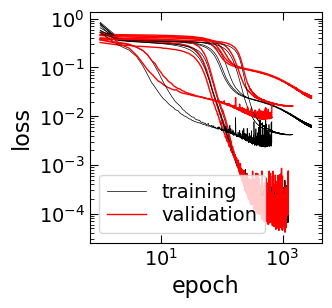

17 min 33.44 seconds

File_Stem: hyperopt/seq/psin/shallow/stdXstdY/dn2/act/relu
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... found data set of dimension 4 with targets of dimension 1
... found 2500 samples
... fraction 0.800 (2000 samples) will be used for training
... will search over 3 iterations of 64 configurations
... will store best 10 networks in ensemble
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 16 process(es)
[....................] 100% done
[..................  ] 95% done... defining and loading NetworkEnsembleObject
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
Best test stats:
... hyperopt/seq/psin/shallow/stdXstdY/dn2/

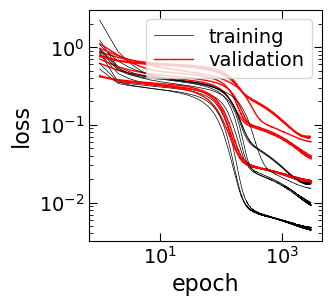

15 min 53.35 seconds

File_Stem: hyperopt/seq/psin/shallow/stdXstdY/dn2/act/lrelu
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... found data set of dimension 4 with targets of dimension 1
... found 2500 samples
... fraction 0.800 (2000 samples) will be used for training
... will search over 3 iterations of 64 configurations
... will store best 10 networks in ensemble
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 16 process(es)
[....................] 100% done
... defining and loading NetworkEnsembleObject
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
Best test stats:
... hyperopt/seq/psin/shallow/stdXstdY/dn2/act/lrelu/ensemble/net_r0: 3.3

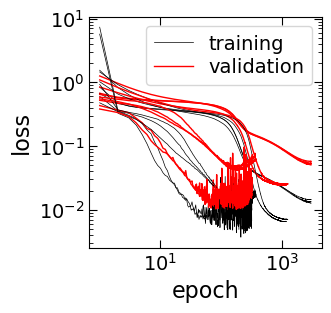

11 min 39.69 seconds

File_Stem: hyperopt/seq/psin/shallow/stdXstdY/dn2/act/sin
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... found data set of dimension 4 with targets of dimension 1
... found 2500 samples
... fraction 0.800 (2000 samples) will be used for training
... will search over 3 iterations of 64 configurations
... will store best 10 networks in ensemble
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 16 process(es)
[....................] 100% done
[.................   ] 85% done... defining and loading NetworkEnsembleObject
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
Best test stats:
... hyperopt/seq/psin/shallow/stdXstdY/dn2/a

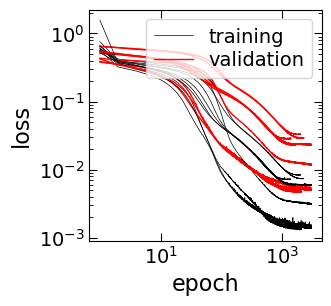

18 min 44.74 seconds

File_Stem: hyperopt/seq/psin/shallow/stdXstdY/dn2/act/splus
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... found data set of dimension 4 with targets of dimension 1
... found 2500 samples
... fraction 0.800 (2000 samples) will be used for training
... will search over 3 iterations of 64 configurations
... will store best 10 networks in ensemble
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 16 process(es)
[....................] 100% done
[..................  ] 92% done... defining and loading NetworkEnsembleObject
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
Best test stats:
... hyperopt/seq/psin/shallow/stdXstdY/dn2

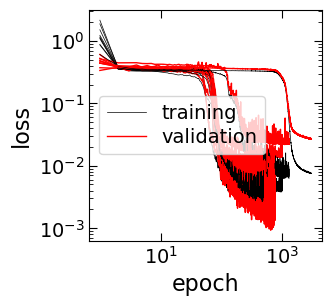

13 min 35.25 seconds

File_Stem: hyperopt/seq/psin/shallow/stdXstdY/dn2/act/requ
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... found data set of dimension 4 with targets of dimension 1
... found 2500 samples
... fraction 0.800 (2000 samples) will be used for training
... will search over 3 iterations of 64 configurations
... will store best 10 networks in ensemble
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 16 process(es)
[....................] 100% done
[................... ] 99% done... defining and loading NetworkEnsembleObject
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
Best test stats:
... hyperopt/seq/psin/shallow/stdXstdY/dn2/

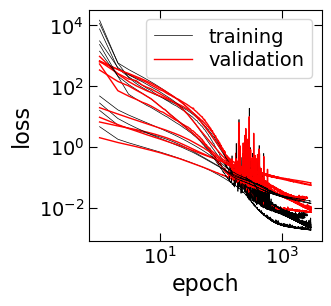

23 min 15.37 seconds

all done!
100 min 41.85 seconds



In [15]:
if Standardize_X & Standardize_Y & Fixed_Width:
    Optimize = True
    start_time_all = time()
    
    Activations = ['tanh','relu','lrelu','sin','splus']
    if Shallow:
        Activations += ['requ'] # ReQU leads to exploding gradients in deep networks
        
    residual_act = {}
    Example_Root_Act = Example_Root + '/act'
    Plot_Root_Act = Plot_Root + '_act'
    
    setup_dict_act = copy.deepcopy(setup_dict)
    setup_dict_act['ensemble'] = True
    setup_dict_act['ensemble_size'] = 10
    
    for act in Activations:
        Example_Stem_Act = Example_Root_Act + '/' + act
        
        File_Stem = 'hyperopt/' + Example_Stem_Act
        print('File_Stem:',File_Stem)
        
        setup_dict_act['file_stem'] = File_Stem
        setup_dict_act['htypes'] = [act]

        start_time = time()
        hopt_act = HyperOpt(setup_dict=setup_dict_act)
        
        if Optimize:
            neo_act = hopt_act.optimize()
        else:
            neo_act = hopt_act.load() # network ensemble object
            print('Loaded ensembled network')

        
        Ypred_act = neo_act.predict(X_test)
        show_keys = ['L','wt_decay','n_layer','atypes','reg_fun']
        
        print('Best test stats:')
        for key in neo_act.keys:
            print('... '+key+': {0:.3e}'.format(neo_act.ensemble[key]['teststat']))
            for pkey in show_keys:
                print('... ... '+pkey+':',neo_act.ensemble[key]['net'].params[pkey])
                if pkey == 'atypes':
                    if 'lrelu' in neo_act.ensemble[key]['net'].params[pkey]:
                        print('... ... lrelu_slope: {0:.2e}'.format(neo_act.ensemble[key]['net'].params['lrelu_slope']))
            print('... ... check_after: {0:d}'.format(neo_act.ensemble[key]['ptrain']['check_after']))
            print('... ... lrate: {0:.2e}'.format(neo_act.ensemble[key]['ptrain']['lrate']))
        
        print('No. of free params optimized:')
        ens_act_avg_Nwts = []
        for key in neo_act.keys:
            nwts_this = neo_act.ensemble[key]['net'].calc_N_freeparams()
            print('... '+key+': {0:d}'.format(nwts_this))
            ens_act_avg_Nwts.append(nwts_this)
        ens_act_avg_Nwts = np.mean(ens_act_avg_Nwts)
        print('... average: {0:.1f}'.format(ens_act_avg_Nwts))
        
        plt.figure(figsize=(3,3))
        plt.yscale('log')
        plt.xscale('log')
        plt.xlabel('epoch')
        plt.ylabel('loss')
        for n in range(len(neo_act.keys)):
            key = neo_act.keys[n]
            net_this = neo_act.ensemble[key]['net']
            plt.plot(net_this.epochs,net_this.training_loss,'k-',lw=0.5,label='training' if n==0 else None)
            plt.plot(net_this.epochs,net_this.val_loss,'r-',lw=1,label='validation' if n==0 else None)
            del net_this
        plt.legend()
        plt.show()
        
        residual_act[act] = np.squeeze(Ypred_act/(Y_test + 1e-15) - 1)
        
        ut.time_this(start_time)
    print('all done!')
    ut.time_this(start_time_all)

median +- 1sigma
... tanh: -0.0185 + 4.6809 - 4.3711 %
... relu: -0.6915 + 24.3986 - 8.2751 %
... lrelu: -0.6497 + 17.4300 - 7.6721 %
... sin: 0.0467 + 3.3044 - 2.6061 %
... splus: -0.1497 + 4.6432 - 6.2817 %
... requ: 0.1490 + 4.5851 - 1.8911 %
Writing to file: hyperopt/plots/seq_psin_shallow_stdXstdY_dn2_act.png


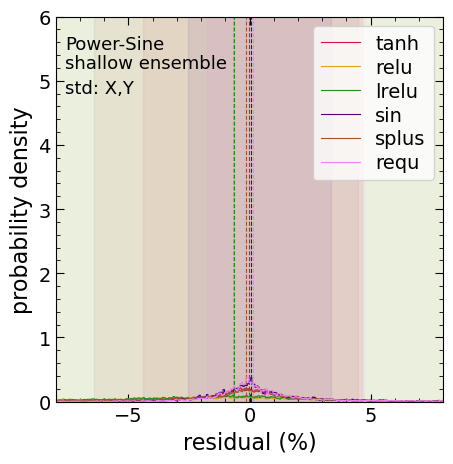

In [16]:
if Standardize_X & Standardize_Y & Fixed_Width:
    res_act_16pc = {}
    res_act_med  = {}
    res_act_84pc = {}
    
    bins = np.linspace(-25,25,801)
    bin_mid = 0.5*(bins[1:]+bins[:-1])
    hist_act = {}
    
    cols = ['crimson','goldenrod','forestgreen','indigo','sienna','violet']
    cols_dict = {Activations[a]:cols[a] for a in range(len(Activations))}
    
    print('median +- 1sigma')
    for act in Activations:
        res_act_16pc[act] = np.percentile(residual_act[act],16)*100
        res_act_med[act]  = np.median(residual_act[act])*100
        res_act_84pc[act] = np.percentile(residual_act[act],84)*100
        hist_this,bins = np.histogram(residual_act[act]*100,bins=bins,density=False)
        hist_act[act] = hist_this/residual_act[act].size/(bins[1]-bins[0])
        print('... '+act+': {0:.4f} + {1:.4f} - {2:.4f} %'.format(res_act_med[act],res_act_84pc[act]-res_act_med[act],
                                                                  res_act_med[act]-res_act_16pc[act]))
    
    plt.figure(figsize=(5,5))
    XLoc = 1.5 if Ftype=='gf1d' else 8.0
    dXLoc = 0.1 if Ftype=='gf1d' else 0.4
    plt.xlim(-XLoc,XLoc)
    plt.ylim(0,6)
    plt.xlabel('residual (%)')
    plt.ylabel('probability density')
    for act in Activations:
        plt.plot(bin_mid,hist_act[act],'-',c=cols_dict[act],lw=0.8,drawstyle='steps',label=act)
        plt.axvline(res_act_med[act],c=cols_dict[act],ls='--',lw=0.8)
        plt.fill_betweenx(np.linspace(0,7,10),res_act_16pc[act],res_act_84pc[act],color=cols_dict[act],alpha=0.075)
    plt.minorticks_on()
    plt.legend(loc='upper right')
    plt.text(-XLoc+dXLoc,5.5,Example_Text,fontsize=FS3)
    plt.text(-XLoc+dXLoc,5.2,Depth_Str_Root+' ensemble',fontsize=FS3)
    plt.text(-XLoc+dXLoc,4.8,Std_Text,fontsize=FS3)
    if Save_Fig:
        outfile = Plot_Stem + '/' + Plot_Root_Act + '.png'
        print('Writing to file: '+outfile)
        plt.savefig(outfile,bbox_inches='tight')
    else:
        plt.show()

### Classification example: Two moons

#### Data setup

In [ ]:
from sklearn.datasets import make_moons

#### Training & testing samples

In [ ]:
FtypeClass = 'moons'

ExDictClass = {'moons':{'root':'moons_','text':'Two Moons',
                        'noise':0.1,'neg_labels':False}
              }

if FtypeClass not in ExDictClass.keys():
    raise Exception("FTypeClass must be one of ["+','.join(key for key in list(ExDict.keys()))+']')

Example_Class_Root = Family + '/' + ExDictClass[FtypeClass]['root'] + Depth_Str + DN_Str
Plot_Class_Root = Family + '_' + ExDictClass[FtypeClass]['root'][:-1] + '_' + Plot_Str_Root + '_' + DN_Str[1:]
print(Example_Class_Root,Plot_Class_Root)

Example_Class_Text = ExDictClass[FtypeClass]['text']
noise = ExDictClass[FtypeClass]['noise']
Neg_Labels = ExDictClass[FtypeClass]['neg_labels']


In [ ]:
start_time = time()

print('Generating data for '+Example_Class_Text+' family...')

seed = 1983
rng = np.random.RandomState(seed)

#################################################
# Training set
print('... training sample')
n_train = 2500
if FtypeClass == 'moons':
    X_train,Y_train = make_moons(n_samples=n_train,noise=noise,random_state=rng)
else:
    pass
    
X_train = X_train.T
Y_train = ml.rv(Y_train)

print('... sample of size {0:d} created'.format(n_train))
#################################################
# Testing set
print('... testing sample')
n_test = 2000
if FtypeClass == 'moons':
    X_test,Y_test = make_moons(n_samples=n_test,noise=noise,random_state=rng)
else:
    pass
    
X_test = X_test.T
Y_test = ml.rv(Y_test)
print('... sample of size {0:d} created'.format(n_test))
#################################################
print('... done')
ut.time_this(start_time)

cmoon = ['crimson','indigo']
plt.figure(figsize=(2,2))
plt.scatter(X_train[0],X_train[1],c=[cmoon[Y_train[0,n]] for n in range(Y_train.shape[1])],s=0.2)
plt.show()
if X_train.shape[0] > 2:
    plt.figure(figsize=(2,2))
    plt.scatter(X_train[0],X_train[2],c=[cmoon[Y_train[0,n]] for n in range(Y_train.shape[1])],s=0.2)
    plt.show()
    # plt.figure(figsize=(2,2))
    # plt.scatter(X_train[1],X_train[2],c=[cmoon[Y_train[0,n]] for n in range(Y_train.shape[1])],s=0.2)
    # plt.show()

plt.figure(figsize=(2,2))
plt.scatter(X_test[0],X_test[1],c=[cmoon[Y_test[0,n]] for n in range(Y_test.shape[1])],s=0.4)
plt.show()
if X_test.shape[0] > 2:
    plt.figure(figsize=(2,2))
    plt.scatter(X_test[0],X_test[2],c=[cmoon[Y_test[0,n]] for n in range(Y_test.shape[1])],s=0.2)
    plt.show()
    # plt.figure(figsize=(2,2))
    # plt.scatter(X_test[1],X_test[2],c=[cmoon[Y_test[0,n]] for n in range(Y_test.shape[1])],s=0.2)
    # plt.show()


#### Network setup and training
*single 2-layer network with 3 neurons and tanh activation, trained for 1000 epochs with lrate=1e-3, is enough for the two-moons problem*

In [ ]:
Max_Epoch = 3000 if FtypeClass=='moons' else 300000

##### Non-ensembled

In [ ]:
Optimize = True

Example_Stem_Single = Family + '/' + Example_Class_Root

File_Stem = 'hyperopt/' + Example_Stem_Single
print('File_Stem:',File_Stem)

Train_Frac = 0.8                               # fraction of input samples to use for training+validation. 
                                               # remaining used for arch and hyperparam comparisons.
Check_After = 300                              # epoch after which to activate validation (early stopping) checks
Val_Frac = 0.2                                 # fraction of Train_Frac to use for validation, i.e. early stopping criterion.
Arch_Type = 'emulator:'+Depth_Str_Root         # None or one of ['emulator:deep','emulator:shallow','no_reg','autoenc']. 
Min_Layer = 1 if Shallow else 6                # minimum number of layers (x4 for deep)
Max_Layer = 4 if Shallow else 7                # maximum number of layers (x4 for deep)
Max_Ex = [0,2,4] if Shallow else [8,9]         # int or list of ints. number of nodes in excess of input dimension 
                                               # (currently forced to be constant across layers)
HTypes = ['relu','tanh']                       # None or subset of ['tanh','relu','lrelu','requ','splus'] 
LRates = [3e-4,1e-3]                           # None or list of floats: learning rates
Wt_Decays = [0.0,0.1]                          # non-empty list of floats: weight decay values
N_Iter = 6                                     # number of iterations for each choice of arch and hyperparams
Loss_Type = 'nll'                              # one of ['square','hinge','nll','nllm']
Seed = None                                    # None or int, random number seed.
Parallel = True                                # train networks in parallel
NProc = 10                                     # number of concurrent processes (only relevant if Parallel = True)

start_time = time()
hopt = HyperOpt(X_train,Y_train,train_frac=Train_Frac,arch_type=Arch_Type,standardize_X=Standardize_X,standardize_Y=Standardize_Y,
              max_ex=Max_Ex,min_layer=Min_Layer,max_layer=Max_Layer,neg_labels=Neg_Labels,
              val_frac=Val_Frac,n_iter=N_Iter,wt_decays=Wt_Decays,lrates=LRates,htypes=HTypes,check_after=Check_After,
              parallel=Parallel,nproc=NProc,loss_type=Loss_Type,seed=Seed,file_stem=File_Stem,ensemble=False)
if Optimize:
    netc,params_train,bts = hopt.optimize(max_epoch=Max_Epoch)
    print('Best test stat = {0:.3e}'.format(bts))
    print('Setup params: ',netc.params)
    print('Training params: ',params_train)
else:
    netc = hopt.load()
    print('Loaded network with')
    print('...    setup params: ',netc.params)
    params_train,bts = hopt.load_train()
    print('... best test stat: {0:.3e}'.format(bts))
    print('... training params: ',params_train)

print('No. of free params optimized = {0:d}\n'.format(netc.calc_N_freeparams()))

asc = ml.assess_classification(netc.predict(X_test),Y_test,neg_labels=Neg_Labels)
print('Assessment:')
for key in ['precision','recall','F1score']:
    print('... '+key+': {0:.5f}'.format(asc[key]))

plt.figure(figsize=(3,3))
plt.yscale('log')
plt.xscale('log')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.plot(netc.epochs,netc.training_loss,'k-',lw=0.5,label='training')
plt.plot(netc.epochs,netc.val_loss,'r-',lw=1,label='validation')
plt.legend()
plt.show()

Ypred = netc.predict(X_test)
if FtypeClass == 'moons':
    plt.figure(figsize=(2,2))
    plt.scatter(X_test[0],X_test[1],c=[cmoon[int(Ypred[0,n])] for n in range(X_test.shape[1])],s=0.1)
    plt.show()

ut.time_this(start_time)

##### Ensembled

In [ ]:
Optimize = True

Example_Stem_Single = Example_Class_Root + '_ens'

File_Stem = 'hyperopt/' + Example_Stem_Single
print('File_Stem:',File_Stem)

Train_Frac = 0.8                               # fraction of input samples to use for training+validation. 
                                               # remaining used for arch and hyperparam comparisons.
Check_After = 300                              # epoch after which to activate validation (early stopping) checks
Val_Frac = 0.2                                 # fraction of Train_Frac to use for validation, i.e. early stopping criterion.
Arch_Type = 'emulator:'+Depth_Str_Root         # None or one of ['emulator:deep','emulator:shallow','no_reg','autoenc']. 
Min_Layer = 1 if Shallow else 6                # minimum number of layers (x4 for deep)
Max_Layer = 4 if Shallow else 7                # maximum number of layers (x4 for deep)
Max_Ex = [0,2,4] if Shallow else [8,9]         # int or list of ints. number of nodes in excess of input dimension 
                                               # (currently forced to be constant across layers)
HTypes = ['relu','tanh']                       # None or subset of ['tanh','relu','lrelu','requ','splus'] 
LRates = [3e-4,1e-3]                           # None or list of floats: learning rates
Wt_Decays = [0.0,0.1]                          # non-empty list of floats: weight decay values
N_Iter = 6                                     # number of iterations for each choice of arch and hyperparams
Loss_Type = 'nll'                              # one of ['square','hinge','nll','nllm']
Seed = None                                    # None or int, random number seed.
Parallel = True                                # train networks in parallel
NProc = 10                                     # number of concurrent processes (only relevant if Parallel = True)

start_time = time()
hopt = HyperOpt(X_train,Y_train,train_frac=Train_Frac,arch_type=Arch_Type,standardize_X=Standardize_X,standardize_Y=Standardize_Y,
              max_ex=Max_Ex,min_layer=Min_Layer,max_layer=Max_Layer,neg_labels=Neg_Labels,
              val_frac=Val_Frac,n_iter=N_Iter,wt_decays=Wt_Decays,lrates=LRates,htypes=HTypes,check_after=Check_After,
              parallel=Parallel,nproc=NProc,loss_type=Loss_Type,seed=Seed,file_stem=File_Stem,ensemble=True)

if Optimize:
    neoc = hopt.optimize(max_epoch=Max_Epoch)
else:
    neoc = hopt.load() # network ensemble object
    print('Loaded ensembled network')

print('Best test stats:')
for key in neoc.keys:
    print('... '+key+': {0:.3e}'.format(neoc.ensemble[key]['teststat']))
    print(neoc.ensemble[key]['net'].params)
    print(neoc.ensemble[key]['ptrain'])

print('No. of free params optimized:')
ensc_avg_Nwts = []
for key in neoc.keys:
    nwts_this = neoc.ensemble[key]['net'].calc_N_freeparams()
    print('... '+key+': {0:d}'.format(nwts_this))
    ensc_avg_Nwts.append(nwts_this)
ensc_avg_Nwts = np.mean(ensc_avg_Nwts)
print('... average: {0:.1f}'.format(ensc_avg_Nwts))

asc_ens = ml.assess_classification_ensemble(neoc,X_test,Y_test)
print('Assessment (ensemble average):')
for key in ['precision','recall','F1score']:
    print('... '+key+': {0:.5f} +- {1:.5f}'.format(asc_ens[key]['mean'],asc_ens[key]['std']))

plt.figure(figsize=(3,3))
plt.yscale('log')
plt.xscale('log')
plt.xlabel('epoch')
plt.ylabel('loss')
for n in range(len(neoc.keys)):
    key = neoc.keys[n]
    net_this = neoc.ensemble[key]['net']
    plt.plot(net_this.epochs,net_this.training_loss,'k-',lw=0.5,label='training' if n==0 else None)
    plt.plot(net_this.epochs,net_this.val_loss,'r-',lw=1,label='validation' if n==0 else None)
    del net_this
plt.legend()
plt.show()

Ypred = neoc.predict(X_test)
if FtypeClass == 'moons':
    plt.figure(figsize=(2,2))
    plt.scatter(X_test[0],X_test[1],c=[cmoon[int(Ypred[0,n])] for n in range(X_test.shape[1])],s=0.1)
    plt.show()

ut.time_this(start_time)

#### Plot

In [ ]:
cols = ['indigo','crimson']
plt.figure(figsize=(5,3))

ticks = {'precision':[0.2,'precision'],
         'recall':[0.5,'recall'],
         'F1score':[0.8,'$F_{{1}}$ score']}

plt.xlim(0,1)
ymin,ymax = (0.995,1.01) if FtypeClass=='moons' else (0.3,1.1)
plt.ylim(ymin,ymax)
plt.xticks([ticks[key][0] for key in ticks.keys()],
           [ticks[key][1] for key in ticks.keys()],rotation=30)

for key in ticks.keys():
    Label = 'single' if key=='precision' else None
    plt.plot([ticks[key][0]],[asc[key]],c=cols[0],marker='^',ls='none',markersize=7,label=Label)
    Label = 'ensemble' if key=='precision' else None
    plt.errorbar([ticks[key][0]],[asc_ens[key]['mean']],yerr=[asc_ens[key]['std']],c=cols[1],
                 capsize=5,marker='o',ls='none',markersize=5,label=Label)
xtext = 0.05
ytext1 = 1.008 if FtypeClass=='moons' else 1.0
ytext2 = 1.006 if FtypeClass=='moons' else 0.9
ytext3 = 1.0045 if FtypeClass=='moons' else 0.825
plt.text(xtext,ytext1,Example_Class_Text,fontsize=FS3)
plt.text(xtext,ytext2,Depth_Str_Root+' nets',fontsize=FS3)
plt.text(xtext,ytext3,Std_Text,fontsize=FS3)
ytext4 = 1.004 if FtypeClass=='moons' else 0.8 
ytext5 = 1.0025 if FtypeClass=='moons' else 0.7
plt.text(0.6,ytext4,'$N_{{\\rm wts}} = {0:d}$'.format(netc.calc_N_freeparams()),fontsize=FS3,c=cols[0])
plt.text(0.55,ytext5,'$\\langle \\, N_{{\\rm wts}} \\, \\rangle = {0:.1f}$'.format(ensc_avg_Nwts),fontsize=FS3,c=cols[1])

plt.legend(loc='upper right')
if FtypeClass=='moons':
    plt.axhline(1.0,c='k',ls=':',lw=1)

if Save_Fig:
    outfile = Plot_Stem + '/' + Plot_Class_Root + '.png'
    print('Writing to file: '+outfile)
    plt.savefig(outfile,bbox_inches='tight')
else:
    plt.show()


## Optimization of `BiSequential`